<a href="https://colab.research.google.com/github/bhavana-ux618/thiranex_internship/blob/main/Thiranex_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Titanic Survival Prediction

**Step 1: Setup & Load data**

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc

# Set visual style
sns.set(style="whitegrid")
%matplotlib inline

# Load the Titanic dataset (built into Seaborn)
df = sns.load_dataset('titanic')
print("--- First 5 Rows ---")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\n--- Data Info ---")
print(df.info())

--- First 5 Rows ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Shape: (891, 15)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------  

**Step 2: Data Preprocessing:**

Clean the data, handle missing values, and encode text data.

In [4]:
# Work on a copy
data = df.copy()

# --- 1. Handle Missing Values ---
# Drop 'deck' (too many missing), 'embark_town' (keep 'embarked' instead)
data = data.drop(['deck', 'embark_town', 'alive'], axis=1)

# Fill 'age' with median
data['age'] = data['age'].fillna(data['age'].median())

# Fill 'embarked' with mode
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# --- 2. Encode Categorical Variables ---
# Convert 'sex' and 'embarked' to numbers
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex'])
data['embarked'] = le.fit_transform(data['embarked'])

# --- 3. Feature Selection ---
# Select features (X) and target (y)
X = data[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = data['survived']

print("--- Processed Features ---")
print(X.head())
print(f"\nTarget Distribution:\n{y.value_counts()}")

--- Processed Features ---
   pclass  sex   age  sibsp  parch     fare  embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2

Target Distribution:
survived
0    549
1    342
Name: count, dtype: int64


**Step 3: Split Data & Scale Features:**

In [5]:
# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 712
Testing set size: 179


**Step 4: Train Multiple Models:**

Train and compare 3 different algorithms.

In [6]:
# Dictionary to store models and results
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

# Train each model
for name, model in models.items():
    print(f"Training {name}...")

    # Use scaled data for LogisticRegression, original for Tree models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"  Accuracy: {results[name]['accuracy']:.4f}\n")

# --- Compare Accuracies ---
print("--- MODEL COMPARISON ---")
for name, res in results.items():
    print(f"{name}: {res['accuracy']*100:.2f}%")

Training Logistic Regression...
  Accuracy: 0.8045

Training Decision Tree...
  Accuracy: 0.7821

Training Random Forest...
  Accuracy: 0.8212

--- MODEL COMPARISON ---
Logistic Regression: 80.45%
Decision Tree: 78.21%
Random Forest: 82.12%


**Step 5: Evaluate Performance:**

A. Visualize Confusion Matrix (Best Model)

Best Model: Random Forest (Accuracy: 82.12%)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



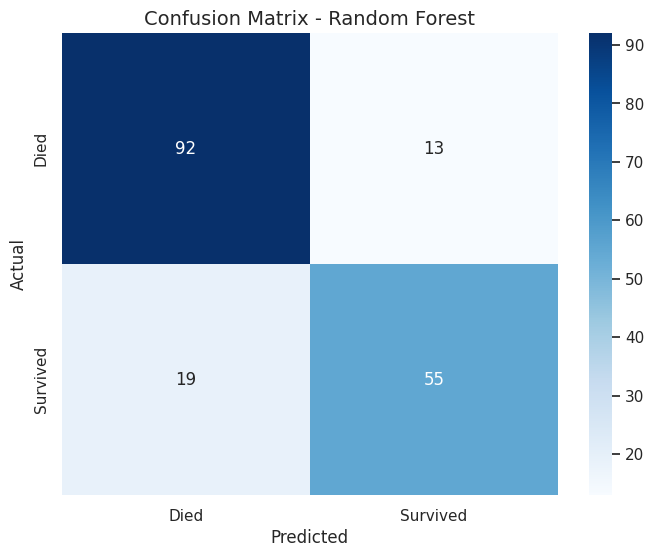

In [7]:
# Select the best model based on accuracy
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_result = results[best_model_name]

print(f"Best Model: {best_model_name} (Accuracy: {best_result['accuracy']*100:.2f}%)")
print("\n--- Classification Report ---")
print(classification_report(y_test, best_result['y_pred']))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

B. Visualize ROC Curve (Compare All Models)

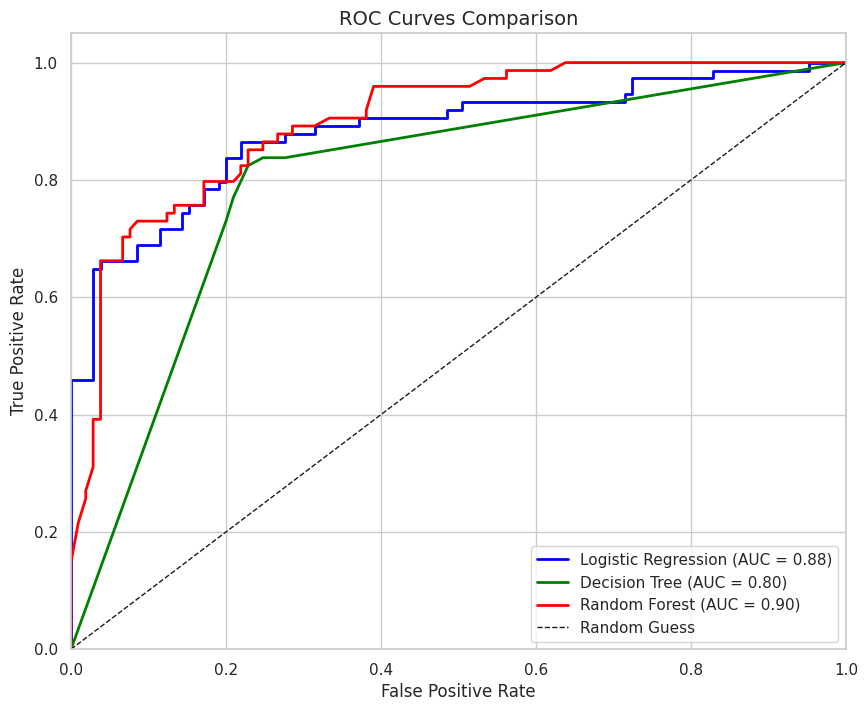

In [8]:
# Plot ROC Curve for all models
plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, thresholds = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.show()

**Step 6: Feature Importance (Bonus):**

See which factors matter most in the Random Forest model.

/tmp/ipykernel_1835/3893481366.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette="viridis")


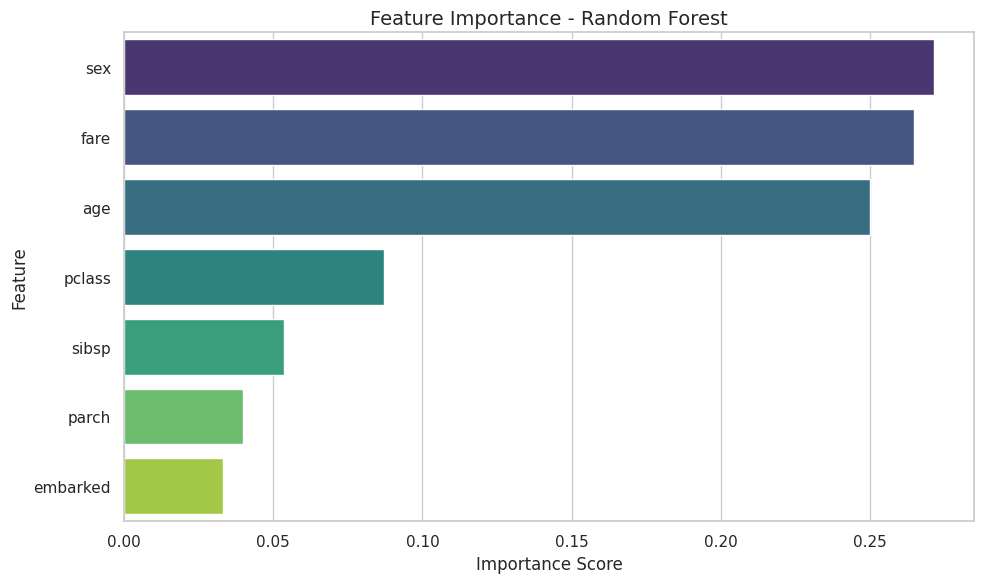

In [9]:
# Using the best Tree-based model
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette="viridis")
plt.title('Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()